# Insights Generation

This notebook try to answer **where is road death risk concentrated and what should be done**

| Lens | Finding |
|---|---|
| WHEN | The road kills most when it is quiet, 6.7% death rate at 4am, 3x the evening rush |
| WHO (young) | One in four deaths of 18 to 24 year olds happens on a weekend night |
| WHO (senior) | The pedestrian share of deaths is 4x higher for seniors, mostly at crossings |
| WHAT | Deaths dropped for every road user except pedestrians (+5% since 2006) |
| HOW and WHY | 2 in 3 deaths involve a lane drift or the vehicle it hits |
| WHERE 1 (rural crash) | A rural crash is nearly 5x deadlier than an urban one |
| WHERE 2 (killer road) | *Départemental* roads carry 61% of all deaths, mostly undivided two lane |
| WHERE 3 (map) | Accidents cluster in cities, deaths scatter across the rural network |


## 1. Library and Setup

In [ ]:
import math
import re
import textwrap
import time
from pathlib import Path

import numpy as np
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots

PATH = r"C:\Users\User\.cache\kagglehub\datasets\ahmedlahlou\accidents-in-france-from-2005-to-2016\versions\2"
ROOT = Path.cwd().resolve().parent  
CHARTS = ROOT / "charts"
CHARTS.mkdir(exist_ok=True)

In [ ]:
def save_fig(fig, name, w, h, scale):
    """Never overwrite: move any existing export to archive/charts first."""
    dest = CHARTS / name
    if dest.exists():
        arch = ROOT / "archive" / "charts"
        arch.mkdir(parents=True, exist_ok=True)
        stamp = time.strftime("%Y%m%d-%H%M%S")
        dest.rename(arch / f"{dest.stem}.{stamp}.png")
    fig.write_image(dest, width=w, height=h, scale=scale)

# Palette
BLUE = "#046A38"
LGREEN = "#86BC25"
GRAY = "#a7a8aa"
DARK = "#53565A"
SURFACE = "#ffffff"
INK = "#000000"
SECONDARY = "#53565A"
MUTED = "#97999B"
TEAL = "#0097A9"
GRID = "#e4e4e2"
BASELINE = "#c8c9c7"
FONT = "Arial, sans-serif"

W, H, SCALE = 630, 430, 2

_TAGS = re.compile(r"<[^>]+>")


# helper functions
def G(s):
    """Emphasize a word/number in signature green bold (narration highlight)."""
    return f'<span style="fill:{LGREEN}"><b>{s}</b></span>'


def Gp(phrase):
    """Emphasize a multi-word phrase (tagged word by word so line wraps stay safe)."""
    return " ".join(G(w) for w in phrase.split())


def wrap_markup(text, width):
    """textwrap.wrap equivalent that ignores markup tags when measuring line width.
    Spaces inside tags are protected so a tag is never split across lines."""
    text = _TAGS.sub(lambda m: m.group(0).replace(" ", "\x00"), text)
    lines, cur, n = [], [], 0
    for w in text.split():
        v = len(_TAGS.sub("", w.replace("\x00", " ")))
        add = v if not cur else v + 1
        if cur and n + add > width:
            lines.append(" ".join(cur))
            cur, n = [w], v
        else:
            cur.append(w)
            n += add
    if cur:
        lines.append(" ".join(cur))
    return [ln.replace("\x00", " ") for ln in lines]


def save_pair(fig, name):
    """Export twice per chart, full version and a plain one without title/narration."""
    save_fig(fig, name, W, H, SCALE)
    fig.update_layout(title=dict(text="", subtitle=dict(text="")), margin=dict(t=24))
    save_fig(fig, name.replace(".png", "_plain.png"), W, H, SCALE)


def base_layout(title, narration, wrap=86):
    lines = wrap_markup(narration, wrap)
    sub = "<br>".join(lines)
    return dict(
        title=dict(
            text=f"<b>{title}</b>",
            font=dict(family=FONT, size=21, color=INK), x=0.015, xanchor="left",
            automargin=True, pad=dict(t=10, b=6),
            subtitle=dict(text=sub, font=dict(family=FONT, size=14, color=SECONDARY)),
        ),
        paper_bgcolor=SURFACE, plot_bgcolor=SURFACE,
        font=dict(family=FONT, size=14, color=MUTED),
        margin=dict(l=10, r=14, t=52 + 20 * len(lines), b=10),
        showlegend=False,
        xaxis=dict(showgrid=False, linecolor=BASELINE, tickfont=dict(color=MUTED, size=14), zeroline=False),
        yaxis=dict(gridcolor=GRID, zeroline=False, tickfont=dict(color=MUTED, size=14)),
    )

In [3]:
car = pd.read_csv(f"{PATH}\\caracteristics.csv", encoding="latin-1", low_memory=False)
usr = pd.read_csv(f"{PATH}\\users.csv", encoding="latin-1", low_memory=False)
veh = pd.read_csv(f"{PATH}\\vehicles.csv", encoding="latin-1", low_memory=False)
plc = pd.read_csv(f"{PATH}\\places.csv", encoding="latin-1", low_memory=False)
hol = pd.read_csv(f"{PATH}\\holidays.csv", encoding="latin-1")

usr["killed"] = (usr.grav == 2).astype(int)
car["year"] = 2000 + car.an
car["hour"] = (car.hrmn // 100).clip(0, 23)
car["date"] = pd.to_datetime(dict(year=car.year, month=car.mois, day=car.jour), errors="coerce")
car["dow"] = car.date.dt.dayofweek
u = usr.merge(car[["Num_Acc", "year", "hour", "dow", "date", "agg", "col"]], on="Num_Acc")
u["age"] = u.year - u.an_nais

# day-type rates (used inside the WHEN chart)
hol_dates = set(pd.to_datetime(hol.ds).dt.date)
dow_names = {0: "Mon", 1: "Tue", 2: "Wed", 3: "Thu", 4: "Fri", 5: "Sat", 6: "Sun"}
u["day"] = u.date.dt.date
u["cat"] = u.dow.map(dow_names)
u.loc[u.day.isin(hol_dates), "cat"] = "Holiday"
dt = u.groupby("cat").agg(persons=("killed", "size"), killed=("killed", "sum"))
dt["rate"] = 100 * dt.killed / dt.persons
wk = 100 * u[u.cat.isin(["Mon", "Tue", "Wed", "Thu", "Fri"])].killed.mean()

# user class per person (shared by the WHAT and WHO senior charts, so defined once here)
uv = u.merge(veh[["Num_Acc", "num_veh", "catv"]], on=["Num_Acc", "num_veh"], how="left")
uv["uclass"] = np.select(
    [uv.catu.eq(3), uv.catv.eq(1), uv.catv.isin([2, 30, 31, 32, 33, 34]), uv.catv.eq(7)],
    ["Pedestrians", "Cyclists", "Motorized 2W", "Car occupants"], default="other")

## 2. Insights

### 2.1. WHEN: The road kills most when it is quiet

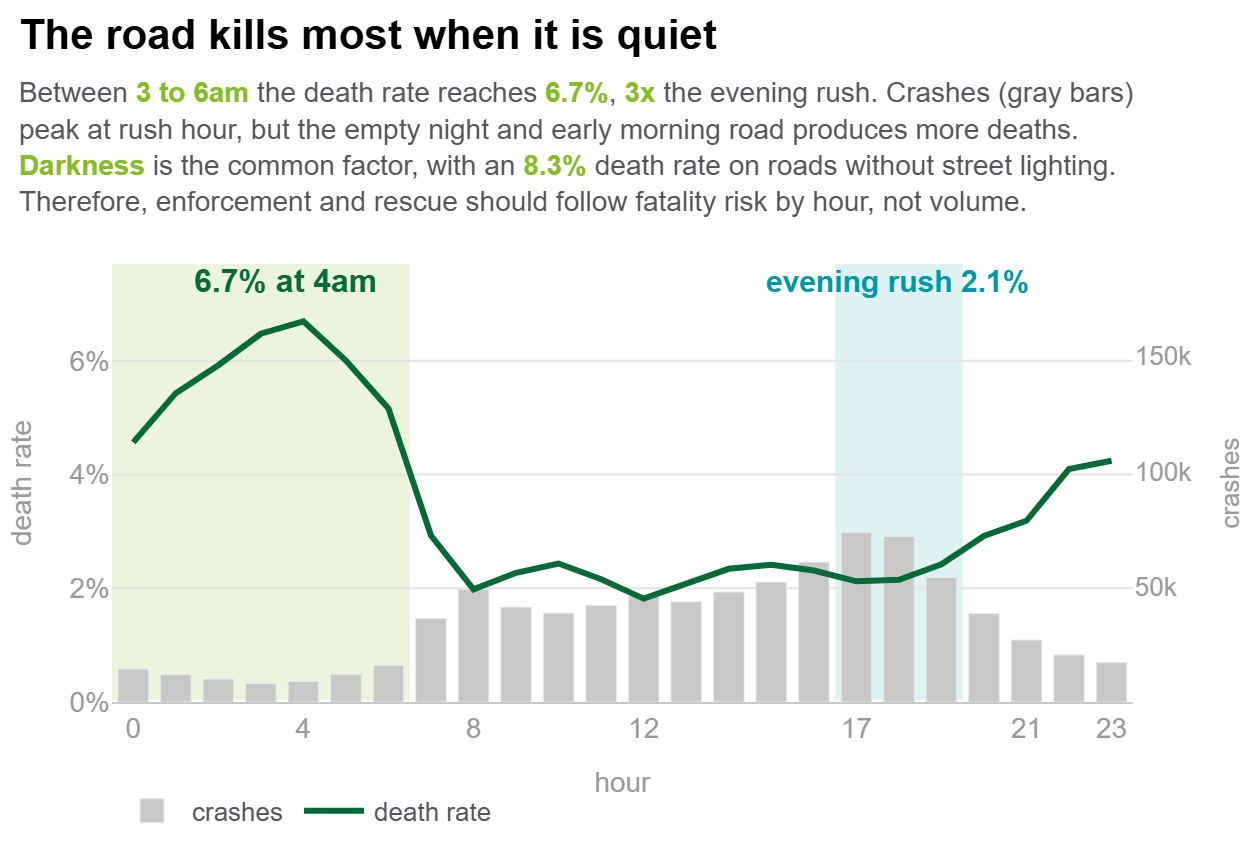

In [ ]:
# Chart 1: Line chart death rate and crashes
t = u.groupby("hour").agg(persons=("killed", "size"), killed=("killed", "sum"))
t["rate"] = 100 * t.killed / t.persons
vol = car.groupby("hour").size() / 1000  # crashes per hour, thousands

fig = make_subplots(specs=[[{"secondary_y": True}]])

fig.add_shape(type="rect", x0=-0.5, x1=6.5, y0=0, y1=1, xref="x", yref="paper",
              fillcolor=LGREEN, opacity=0.16, line_width=0, layer="below")
fig.add_shape(type="rect", x0=16.5, x1=19.5, y0=0, y1=1, xref="x", yref="paper",
              fillcolor=TEAL, opacity=0.13, line_width=0, layer="below")
# crashes on the primary axis (drawn first, sits behind); death rate on the overlay (drawn on top)
fig.add_trace(go.Bar(x=vol.index, y=vol.values, name="crashes", marker_color=BASELINE,
                     width=0.72, hovertemplate="%{x}h: %{y:.1f}k crashes<extra></extra>"),
              secondary_y=False)
fig.add_trace(go.Scatter(x=t.index, y=t.rate, name="death rate", mode="lines",
                         line=dict(color=BLUE, width=3),
                         hovertemplate="%{x}h: %{y:.1f}%<extra></extra>"), secondary_y=True)

lay = base_layout("The road kills most when it is quiet",
                 f"Between {G('3 to 6am')} the death rate reaches {G('6.7%')}, {G('3x')} the "
                 "evening rush. Crashes (gray bars) peak at rush hour, but the empty night and "
                 f"early morning road produces more deaths. {G('Darkness')} is the common factor, "
                 f"with an {G('8.3%')} death rate on roads without street lighting. Therefore, "
                 "enforcement and rescue should follow fatality risk by hour, not volume.", wrap=90)
lay.pop("xaxis")
lay.pop("yaxis")
lay["showlegend"] = True
lay["legend"] = dict(orientation="h", yanchor="top", y=-0.18, x=0, xanchor="left",
                     font=dict(size=13, color=DARK))
lay["margin"]["b"] = 60

fig.update_layout(**lay)
fig.update_yaxes(title_text="crashes", title_font=dict(size=13, color=MUTED), side="right",
                 tickvals=[50, 100, 150], ticktext=["50k", "100k", "150k"],
                 tickfont=dict(color=MUTED, size=13), showgrid=False, range=[0, 190],
                 secondary_y=False)
fig.update_yaxes(title_text="death rate", title_font=dict(size=14, color=MUTED), side="left",
                 ticksuffix="%", tickfont=dict(color=MUTED, size=14), gridcolor=GRID,
                 range=[0, 7.7], secondary_y=True)
fig.update_xaxes(tickvals=[0, 4, 8, 12, 17, 21, 23], title_text="hour",
                 title_font=dict(size=14, color=MUTED), tickfont=dict(color=MUTED, size=14),
                 linecolor=BASELINE, showgrid=False)
fig.add_annotation(x=3.6, y=7.4, xref="x", yref="y2", text="<b>6.7% at 4am</b>", showarrow=False,
                   font=dict(color=BLUE, size=16, family=FONT))
fig.add_annotation(x=18, y=7.4, xref="x", yref="y2", text="<b>evening rush 2.1%</b>",
                   showarrow=False, font=dict(color=TEAL, size=15, family=FONT))
save_pair(fig, "final1_when.png")

from IPython.display import Image, display
display(Image(filename=str(CHARTS / "final1_when.png"), width=760))

A dual axis chart on the hour of day. The gray bars are the number of crashes per hour (right axis), which peak at the evening rush; the green line is the death rate by hour (left axis, share of involved persons killed). The green band marks the night window (0h to 6h) and the teal band the evening rush (17h to 19h). The two lines cross the story, crashes are most numerous at rush hour but each night crash is far deadlier, the death rate peaks at **6.7% at 4am**, roughly **3x** the rush hour's 2.1%. Darkness is the common factor (8.3% death rate on unlit roads). Implication, enforcement and rescue capacity should follow fatality risk by hour, not traffic volume.

### 2.2. WHO (young): Young adults are most at risk on weekend nights

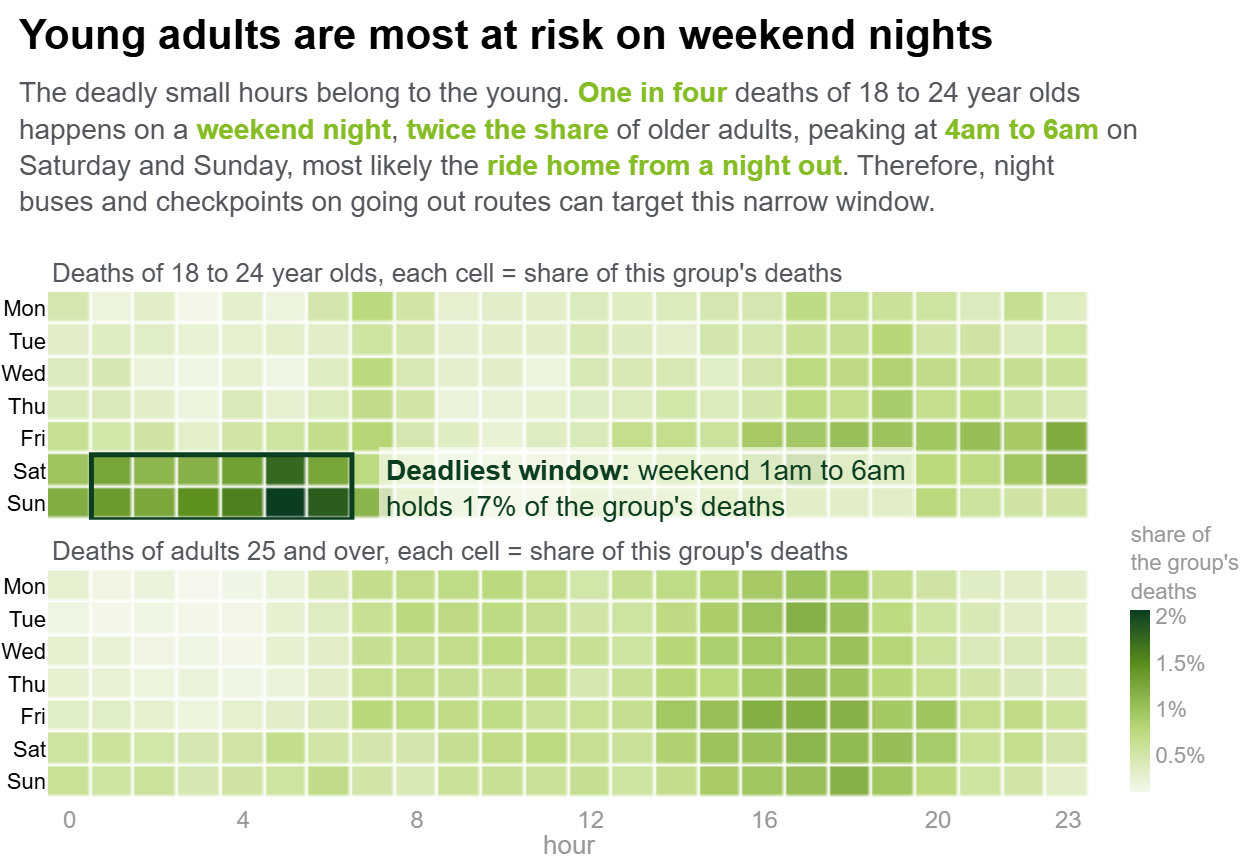

In [ ]:
# Chart 2: Heatmaps of deaths by day and hour young vs older adults
day_rows = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]


def heat_pct(frame):
    """% of the group's deaths falling in each day x hour cell."""
    hmx = frame.groupby(["cat", "hour"]).size().unstack(fill_value=0)
    hmx = hmx.reindex(index=day_rows, columns=range(24), fill_value=0)
    return 100 * hmx / hmx.values.sum()


hm_young = heat_pct(u[(u.age >= 18) & (u.age <= 24) & (u.killed == 1)])
hm_rest = heat_pct(u[(u.age >= 25) & (u.killed == 1)])

fig = make_subplots(rows=2, cols=1, shared_xaxes=True, vertical_spacing=0.10,
                    subplot_titles=("Deaths of 18 to 24 year olds, each cell = share of this group's deaths",
                                    "Deaths of adults 25 and over, each cell = share of this group's deaths"))

for r, hmx in ((1, hm_young), (2, hm_rest)):
    fig.add_trace(go.Heatmap(
        z=hmx.values, x=list(range(24)), y=list(range(7)),
        coloraxis="coloraxis", xgap=1.5, ygap=1.5,
        hovertemplate="%{z:.2f}% of group deaths<extra></extra>"), row=r, col=1)
    
lay = base_layout("Young adults are most at risk on weekend nights",
                 "The deadly small hours belong to the young. "
                 f"{Gp('One in four')} deaths of 18 to 24 year olds happens on a "
                 f"{Gp('weekend night')}, {Gp('twice the share')} of older adults, peaking at "
                 f"{Gp('4am to 6am')} on Saturday and Sunday, most likely the "
                 f"{Gp('ride home from a night out')}. Therefore, night buses and checkpoints on "
                 "going out routes can target this narrow window.")
lay.pop("xaxis")
lay.pop("yaxis")
lay["coloraxis"] = dict(
    colorscale=[[0, "#f4f8ec"], [0.35, "#b8d878"], [0.7, "#5c8f1e"], [1, "#0b3d20"]],
    colorbar=dict(title=dict(text="share of<br>the group's<br>deaths", font=dict(size=11, color=MUTED)),
                  thickness=10, len=0.62, tickfont=dict(size=11, color=MUTED),
                  outlinewidth=0, y=0.28, ticksuffix="%"))
lay["margin"]["b"] = 0
lay["margin"]["t"] += 14
fig.update_layout(**lay)
for a in fig.layout.annotations:  # subplot titles
    a.font = dict(family=FONT, size=13, color=DARK)
    a.x = 0
    a.xanchor = "left"
fig.update_xaxes(tickvals=[0, 4, 8, 12, 16, 20, 23], range=[-0.5, 23.5], showgrid=False,
                 zeroline=False, tickfont=dict(color=MUTED, size=12))
fig.update_xaxes(title=dict(text="hour", font=dict(size=13, color=MUTED), standoff=4),
                 ticklabelstandoff=2, row=2, col=1)
fig.update_yaxes(range=[6.5, -0.5], tickvals=list(range(7)), ticktext=day_rows,
                 showgrid=False, tickfont=dict(color=INK, size=11))
# area highlight on the young panel: weekend, 1am to 6am
win_share = hm_young.loc[["Sat", "Sun"], 1:6].values.sum()
fig.add_shape(type="rect", x0=0.5, x1=6.5, y0=4.5, y1=6.5, row=1, col=1,
              line=dict(color="#0b3d20", width=2.5), fillcolor="rgba(0,0,0,0)")
fig.add_annotation(x=7.1, y=5.5, xanchor="left", align="left", row=1, col=1,
                   text="<b>Deadliest window:</b> weekend 1am to 6am<br>"
                        f"holds {win_share:.0f}% of the group's deaths",
                   showarrow=False, font=dict(color="#0b3d20", size=14, family=FONT),
                   bgcolor="rgba(255,255,255,0.6)", borderpad=3)
save_pair(fig, "final2_young.png")

from IPython.display import Image, display
display(Image(filename=str(CHARTS / "final2_young.png"), width=760))

Two heatmaps show when each group's deaths occur (day of week x hour). Each cell is the share of that group's deaths, so the panels are comparable despite very different group sizes. The young panel (18 to 24) lights up on **weekend nights**, the boxed window (weekend 1am to 6am) holding **17% of the group's deaths**, most likely the ride home from a night out. Adults 25+ instead concentrate on the weekday evening rush. Implication, night transport and checkpoints on hang out routes target a narrow, predictable window.

### 2.3. WHO (senior): The pedestrian share of deaths is 4x higher for seniors

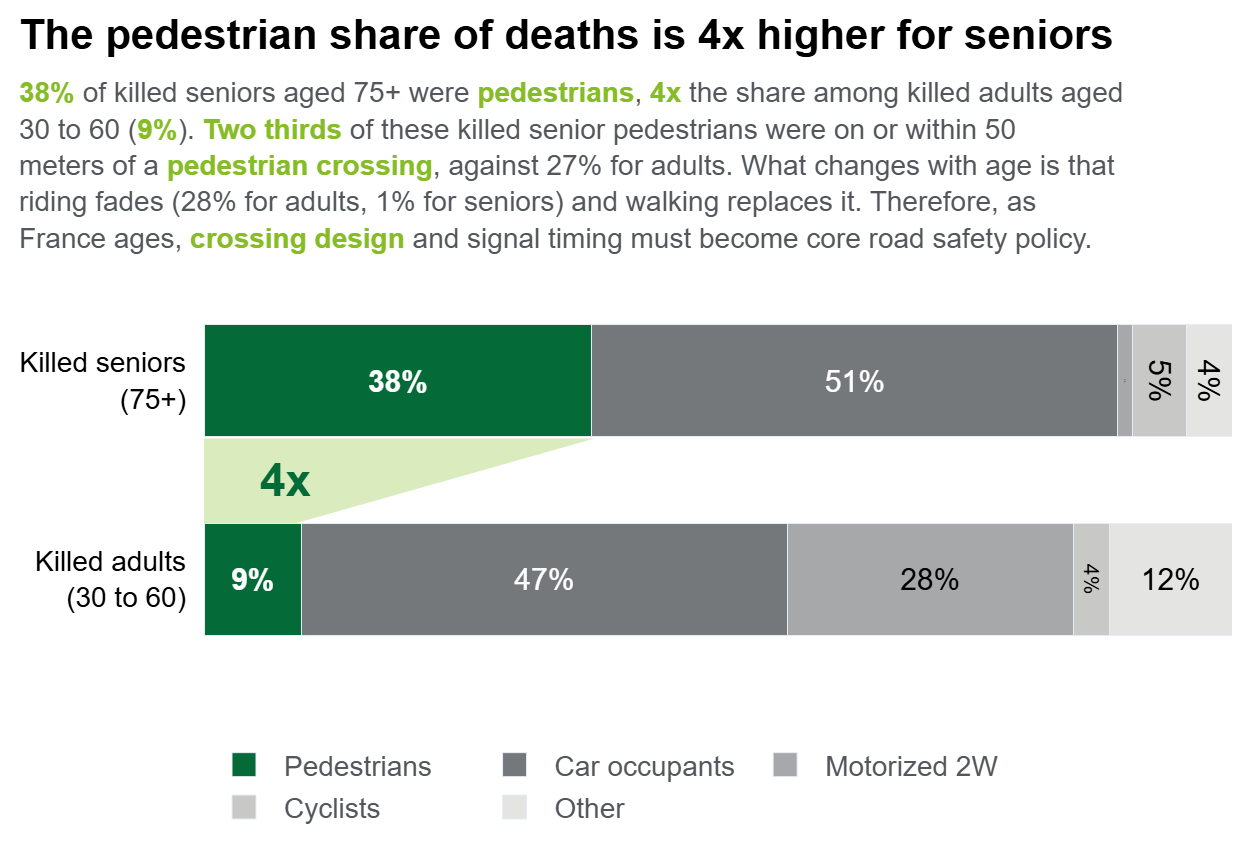

In [ ]:
# Chart 3: Pedestrian share of deaths by age group
mid_k = uv[(uv.age >= 30) & (uv.age <= 60) & (uv.killed == 1)]
old_k = uv[(uv.age >= 75) & (uv.killed == 1)]
mid_share = mid_k.uclass.value_counts(normalize=True).mul(100)
old_share = old_k.uclass.value_counts(normalize=True).mul(100)
groups = ["Killed adults<br>(30 to 60)", "Killed seniors<br>(75+)"]

# numeric bar positions so the bars can grow 25% thicker while the gap between them stays fixed
ypos = [0, 1.1275]
segs = [("Pedestrians", BLUE, "#ffffff"), ("Car occupants", "#75787B", "#ffffff"),
        ("Motorized 2W", "#a7a8aa", "#000000"), ("Cyclists", "#c8c9c7", "#000000"),
        ("Other", "#e4e4e2", "#000000")]

fig = go.Figure()
for name, color, txtcol in segs:
    key = "other" if name == "Other" else name
    vals = [mid_share.get(key, 0), old_share.get(key, 0)]
    bold = name == "Pedestrians"
    fig.add_trace(go.Bar(
        y=ypos, x=vals, orientation="h", name=name, marker_color=color, width=0.6375,
        text=[f"<b>{v:.0f}%</b>" if bold else f"{v:.0f}%" for v in vals],
        textposition="inside", insidetextanchor="middle",
        textfont=dict(color=txtcol, size=15, family=FONT)))
lay = base_layout("The pedestrian share of deaths is 4x higher for seniors",
                 f"{G('38%')} of killed seniors aged 75+ were {G('pedestrians')}, {G('4x')} the "
                 f"share among killed adults aged 30 to 60 ({G('9%')}). "
                 f"{Gp('Two thirds')} of these killed senior pedestrians were on or within 50 "
                 f"meters of a {Gp('pedestrian crossing')}, against 27% for adults. What changes "
                 "with age is that riding fades (28% for adults, 1% for seniors) and walking "
                 f"replaces it. Therefore, as France ages, {Gp('crossing design')} and signal "
                 "timing must become core road safety policy.")
lay["showlegend"] = True
lay["legend"] = dict(orientation="h", x=0, xanchor="left", y=-0.22,
                     font=dict(color=SECONDARY, size=14), traceorder="normal")
lay["xaxis"] = dict(visible=False, range=[0, 100])
lay["yaxis"] = dict(tickvals=ypos, ticktext=groups, range=[-0.436, 1.564],
                    tickfont=dict(color=INK, size=14), showgrid=False, ticklabelstandoff=8)
lay["margin"]["b"] = 34

fig.update_layout(**lay, barmode="stack")
fig.add_shape(type="path", path="M 0,0.32 L 9,0.32 L 38,0.80 L 0,0.80 Z",
              fillcolor="rgba(134,188,37,0.30)", line_width=0, layer="below")
fig.add_annotation(x=8, y=0.56, yref="y", text="<b>4x</b>", showarrow=False,
                   font=dict(color=BLUE, size=23, family=FONT))
save_pair(fig, "final3_seniors.png")

from IPython.display import Image, display
display(Image(filename=str(CHARTS / "final3_seniors.png"), width=760))

Two 100% stacked bars compare what killed seniors (75+) versus adults (30 to 60). The green pedestrian segment jumps from **9% to 38%** (the shaded 4x wedge), while the car occupant share barely moves (47% vs 51%); riding collapses from 28% to 1% and walking replaces it. Two thirds of killed senior pedestrians were at or within 50 meters of a **pedestrian crossing** (vs 27% for adults). Implication, as France ages, crossing design and signal timing become core road safety policy.

### 2.4. WHAT: Deaths dropped for every road user except pedestrians

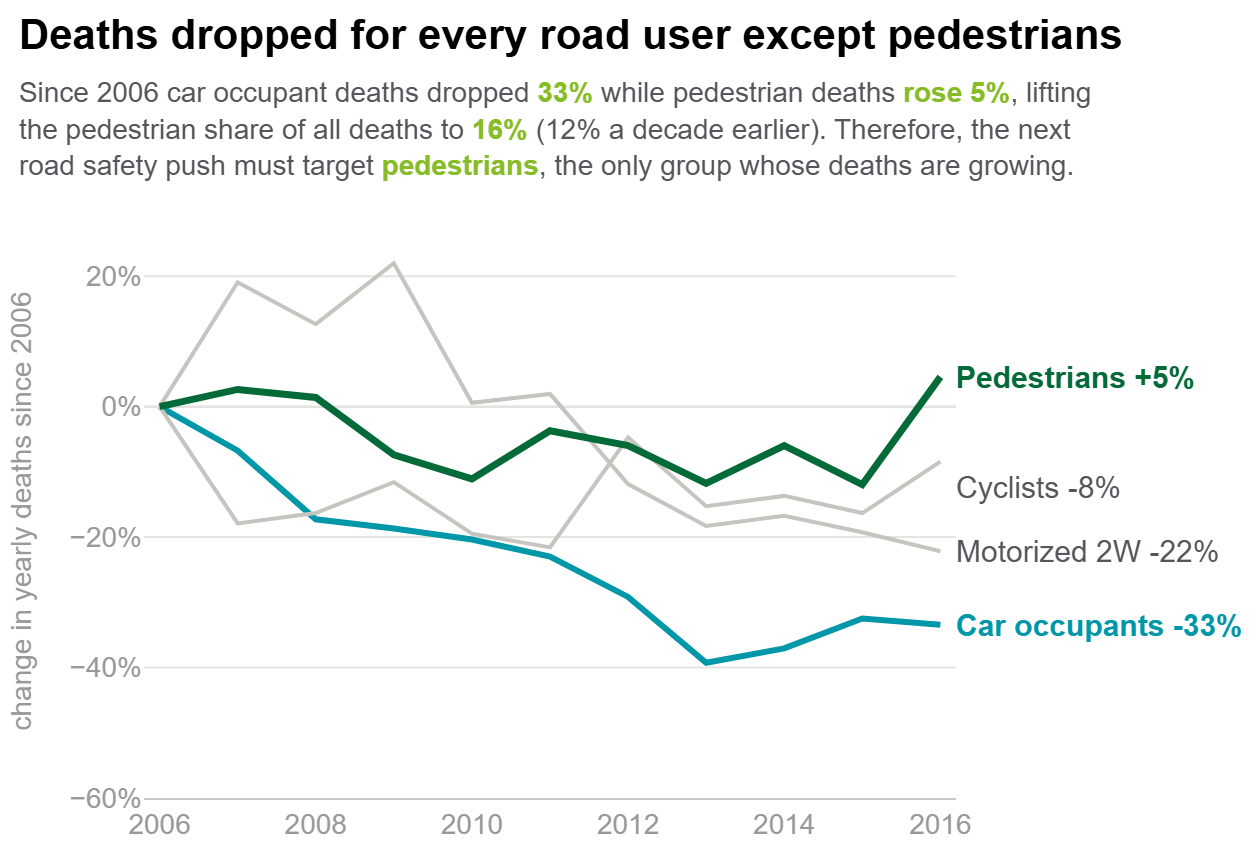

In [ ]:
# Chart 4: Change in yearly deaths by road user since 2006
d = uv[(uv.killed == 1) & (uv.year >= 2006) & (uv.uclass != "other")]
d = d.groupby(["year", "uclass"]).size().unstack()
idx = 100 * d / d.loc[2006]
series = [("Car occupants", TEAL, 3), ("Motorized 2W", "#c6c4be", 2),
          ("Cyclists", "#c6c4be", 2), ("Pedestrians", BLUE, 3.5)]
chg = idx - 100  # percent change in yearly deaths vs 2006

fig = go.Figure()
fig.add_hline(y=0, line=dict(color=BASELINE, width=1), layer="below")
for name, color, wd in series:
    fig.add_trace(go.Scatter(x=chg.index, y=chg[name], mode="lines", name=name,
                             line=dict(color=color, width=wd)))
lay = base_layout("Deaths dropped for every road user except pedestrians",
                 f"Since 2006 car occupant deaths dropped {G('33%')} while pedestrian deaths "
                 f"{Gp('rose 5%')}, lifting the pedestrian share of all deaths to {G('16%')} "
                 "(12% a decade earlier). Therefore, the next road safety push must target "
                 f"{Gp('pedestrians')}, the only group whose deaths are growing.")
lay["xaxis"]["tickvals"] = [2006, 2008, 2010, 2012, 2014, 2016]
lay["xaxis"]["range"] = [2005.8, 2016.2]
lay["yaxis"]["range"] = [-60, 28]
lay["yaxis"]["ticksuffix"] = "%"
lay["yaxis"]["title"] = dict(text="change in yearly deaths since 2006", font=dict(size=14, color=MUTED))
lay["yaxis"]["layer"] = "below traces"
lay["xaxis"]["layer"] = "below traces"
lay["margin"]["r"] = 152

fig.update_layout(**lay)
labels = [("Pedestrians", chg["Pedestrians"].iloc[-1], BLUE, True),
          ("Cyclists", chg["Cyclists"].iloc[-1] - 4, DARK, False),
          ("Motorized 2W", chg["Motorized 2W"].iloc[-1], DARK, False),
          ("Car occupants", chg["Car occupants"].iloc[-1], TEAL, True)]
for name, yv, color, bold in labels:
    txt = f"<b>{name} {chg[name].iloc[-1]:+.0f}%</b>" if bold else f"{name} {chg[name].iloc[-1]:+.0f}%"
    fig.add_annotation(x=2016, y=yv, text=txt, showarrow=False, xanchor="left", xshift=6,
                       font=dict(color=color, size=15, family=FONT))
save_pair(fig, "final4_pedestrians.png")

from IPython.display import Image, display
display(Image(filename=str(CHARTS / "final4_pedestrians.png"), width=760))

The lines track the percent change in yearly deaths since 2006 by road user class. Car occupants finish at **-33%**, motorized two wheelers -22%, cyclists -8%, while **pedestrians end at +5%**, lifting their share of all deaths to 16% (12% a decade earlier). Pedestrians are the only group whose deaths are growing. Implication, the next road safety push must target people on foot.

### 2.5. HOW and WHY: 2 in 3 deaths involve a drifting vehicle or one going straight

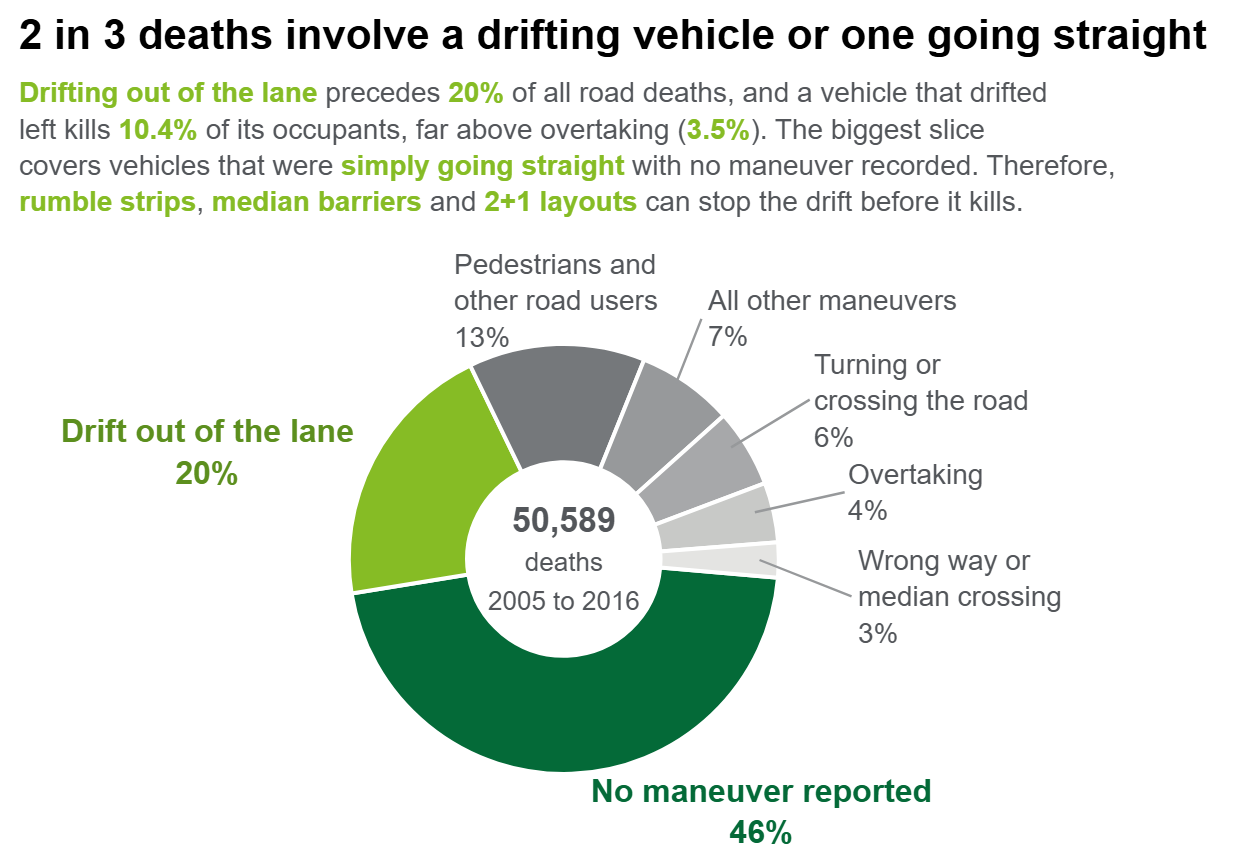

In [ ]:
# Chart 5: Share of deaths by vehicle maneuver
um = u.merge(veh[["Num_Acc", "num_veh", "manv"]], on=["Num_Acc", "num_veh"], how="left")
occ = um[um.catu.isin([1, 2])]  # occupants of the vehicle doing the maneuver
total_deaths = usr.killed.sum()
groups = [
    ("No maneuver reported", [0, 1], BLUE, BLUE),
    ("Drift out of the lane", [13, 14], BLUE, BLUE),
    ("Overtaking", [17, 18], GRAY, DARK),
    ("Wrong way or median crossing", [5, 6], GRAY, DARK),
    ("Turning or crossing the road", [15, 16, 19], GRAY, DARK),
]
known_codes = [c for _, codes, _, _ in groups for c in codes]
rows = []

for name, codes, barcol, txtcol in groups:
    g = occ[occ.manv.isin(codes)]
    rows.append((name, 100 * g.killed.sum() / total_deaths, barcol, txtcol))

other_g = occ[occ.manv.notna() & ~occ.manv.isin(known_codes)]
rows.append(("All other maneuvers", 100 * other_g.killed.sum() / total_deaths, GRAY, DARK))
share_of = dict((r[0], r[1]) for r in rows)
drift_share = share_of["Drift out of the lane"]
drift_left_rate = 100 * occ[occ.manv.eq(13)].killed.mean()
overtake_rate = 100 * occ[occ.manv.isin([17, 18])].killed.mean()
share_of["Pedestrians and other road users"] = 100 - sum(
    share_of[n] for n in ["No maneuver reported", "Drift out of the lane", "All other maneuvers",
                          "Turning or crossing the road", "Overtaking", "Wrong way or median crossing"])

ordered = sorted(share_of.items(), key=lambda kv: kv[1], reverse=True)
order = [n for n, _ in ordered]
values = [v for _, v in ordered]
gray_shades = ["#75787B", "#97999B", "#a7a8aa", "#c8c9c7", "#e4e4e2"]
colors, texts, txt_colors, txt_sizes = [], [], [], []

for i, (n, v) in enumerate(ordered):
    if n == "No maneuver reported":
        colors.append(BLUE)
        txt_colors.append(BLUE)
        txt_sizes.append(16)
        texts.append(f"<b>{n}<br>{v:.0f}%</b>")
    elif n == "Drift out of the lane":
        colors.append(LGREEN)
        txt_colors.append("#5c8f1e")
        txt_sizes.append(16)
        texts.append(f"<b>{n}<br>{v:.0f}%</b>")
    else:
        colors.append(gray_shades.pop(0))
        txt_colors.append(DARK)
        txt_sizes.append(14)
        texts.append("")  
PIE_X = [0.05, 0.57]  


fig = go.Figure(go.Pie(
    labels=order, values=values, text=texts, textinfo="text", textposition="outside",
    marker=dict(colors=colors, line=dict(color="#ffffff", width=2)),
    textfont=dict(size=txt_sizes, family=FONT, color=txt_colors),
    domain=dict(x=PIE_X, y=[0.0, 1.0]),
    sort=False, direction="clockwise", rotation=95, showlegend=False, hole=0.45,
    hovertemplate="%{label}, %{value:.1f}% of all deaths<extra></extra>"))
cx = (PIE_X[0] + PIE_X[1]) / 2

fig.add_annotation(x=cx, y=0.5, xref="paper", yref="paper", showarrow=False,
                   xanchor="center", yanchor="middle", align="center",
                   text=f"<span style='font-size:17px'><b>{int(total_deaths):,}</b></span><br>"
                        "<span style='font-size:13px'>deaths<br>2005 to 2016</span>",
                   font=dict(size=15, color=DARK, family=FONT))
lay = base_layout("2 in 3 deaths involve a drifting vehicle or one going straight",
                 f"{Gp('Drifting out of the lane')} precedes {G(f'{drift_share:.0f}%')} of all "
                 f"road deaths, and a vehicle that drifted left kills {G(f'{drift_left_rate:.1f}%')} "
                 f"of its occupants, far above overtaking ({G(f'{overtake_rate:.1f}%')}). The "
                 f"biggest slice covers vehicles that were {Gp('simply going straight')} with no "
                 f"maneuver recorded. Therefore, {Gp('rumble strips')}, {Gp('median barriers')} "
                 f"and {Gp('2+1 layouts')} can stop the drift before it kills.")
lay.pop("xaxis")
lay.pop("yaxis")
lay["margin"]["l"] = 30
lay["margin"]["r"] = 30
lay["margin"]["b"] = 16
lay["margin"]["t"] += 40
fig.update_layout(**lay)

# leader-line labels for the gray slices (paper coords, arrow from label to slice edge)
PW = W - lay["margin"]["l"] - lay["margin"]["r"]
PH = H - lay["margin"]["t"] - lay["margin"]["b"]
R = min(PW * (PIE_X[1] - PIE_X[0]), PH) / 2
cum = 0
for n, v in ordered:
    mid_deg = 95 + (cum + v / 2) * 3.6
    cum += v
    if n in ("No maneuver reported", "Drift out of the lane"):
        continue
    th = math.radians(90 - mid_deg)
    tip_x = cx + (R * math.cos(th)) / PW
    tip_y = 0.5 + (R * math.sin(th)) / PH
    anchor = "left" if math.cos(th) > 0.2 else "right" if math.cos(th) < -0.2 else "center"
    two_line = {"Wrong way or median crossing": "Wrong way or<br>median crossing",
                "Turning or crossing the road": "Turning or<br>crossing the road",
                "Pedestrians and other road users": "Pedestrians and<br>other road users"}
    off = 22 if math.sin(th) > 0.8 else 46
    extra_down = {"Wrong way or median crossing": 18, "All other maneuvers": -14}.get(n, 0)
    fig.add_annotation(x=tip_x, y=tip_y, xref="paper", yref="paper",
                       ax=math.cos(th) * off, ay=-math.sin(th) * off + extra_down,
                       xanchor=anchor, align="left", showarrow=True,
                       arrowhead=0, arrowwidth=1.2, arrowcolor=MUTED,
                       text=f"{two_line.get(n, n)}<br>{v:.0f}%",
                       font=dict(size=14, color=DARK, family=FONT))
save_pair(fig, "final6_reason.png")

from IPython.display import Image, display
display(Image(filename=str(CHARTS / "final6_reason.png"), width=760))

The donut shows what the casualty's vehicle was doing just before the crash (share of all deaths). The two green slices dominate, **no maneuver reported, 46%** (vehicles simply going straight) and **drift out of the lane, 20%**. A vehicle that drifted left kills 10.4% of its occupants, far above overtaking (3.5%), which everyone fears but which accounts for only 4% of deaths. Implication, rumble strips, median barriers and 2+1 layouts can stop the drift before it kills.

### 2.6. WHERE : A rural crash is five times as deadly

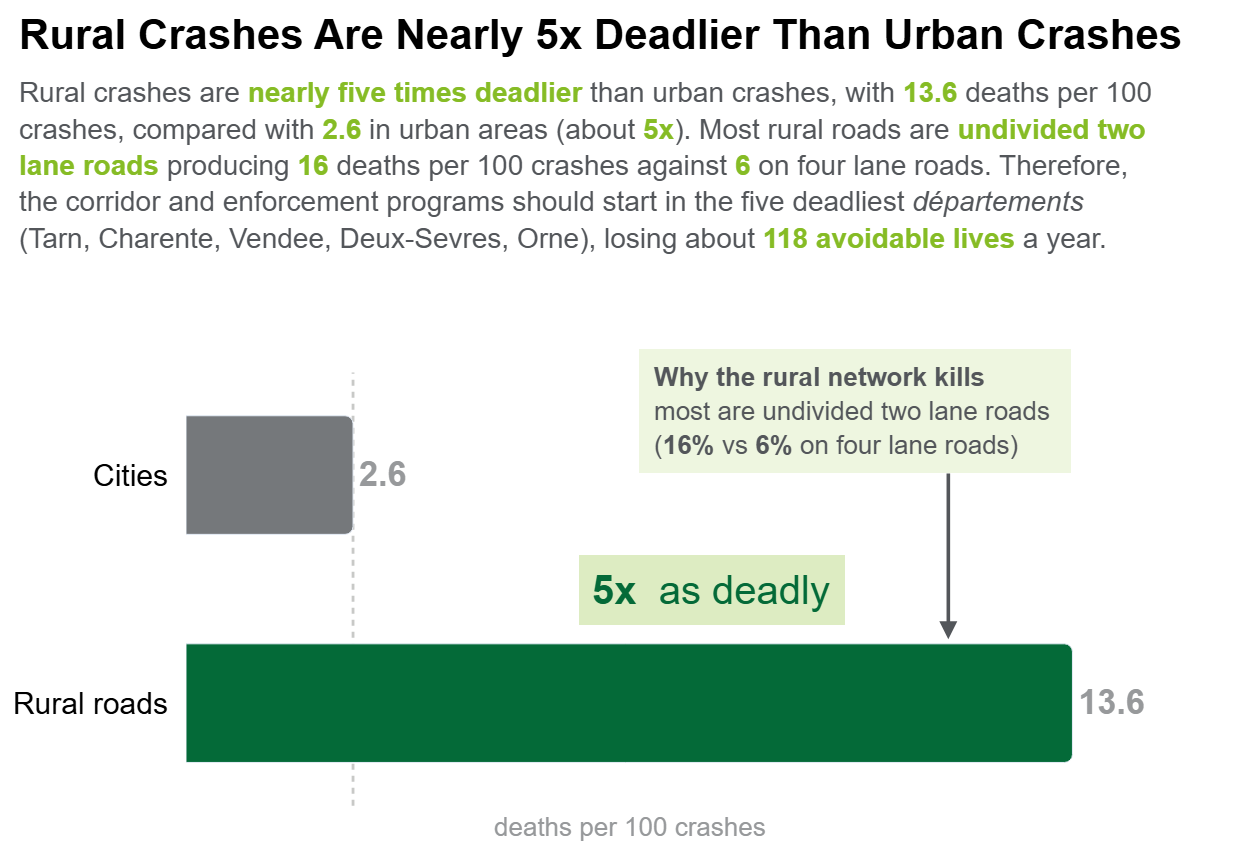

In [ ]:
# Chart 6: Death rate by departement (deaths per 100 persons)
gd = u.merge(car[["Num_Acc", "dep"]], on="Num_Acc").groupby("dep").agg(
    persons=("killed", "size"), killed=("killed", "sum"))
gd = gd[gd.persons > 5000]
gd["rate"] = 100 * gd.killed / gd.persons
nat_rate = 100 * usr.killed.mean()
names = {810: "Tarn", 160: "Charente", 850: "Vendee", 790: "Deux-Sevres", 610: "Orne"}
pr = gd.sort_values("rate").tail(5).copy()   # the five deadliest departements by death rate
pr["name"] = [names.get(i, f"dep {i // 10}") for i in pr.index]
pr["excess_yr"] = (pr.killed - pr.persons * nat_rate / 100) / 12
total_yr = pr.excess_yr.sum()
prio_names = ", ".join(pr.sort_values("rate", ascending=False).name)

# death rate by area, deaths per 100 crashes (total deaths divided by total crashes)
acc_deaths7 = usr.groupby("Num_Acc").killed.sum()
car["_d7"] = car.Num_Acc.map(acc_deaths7).fillna(0)
urban_rate = 100 * car.loc[car["agg"] == 2, "_d7"].mean()   # deaths per 100 crashes
rural_rate = 100 * car.loc[car["agg"] == 1, "_d7"].mean()
mult = rural_rate / urban_rate

# breakdown of rural roads by lane layout, deaths per 100 crashes (why rural roads kill)
al = car[["Num_Acc", "agg", "_d7"]].merge(plc[["Num_Acc", "nbv"]], on="Num_Acc", how="left")
ar = al[al["agg"] == 1]
two_lane = 100 * ar.loc[ar.nbv == 2, "_d7"].mean()
four_lane = 100 * ar.loc[ar.nbv >= 4, "_d7"].mean()

rows7 = ["Rural roads", "Cities"]

fig = go.Figure()
fig.add_trace(go.Bar(
    y=rows7, x=[rural_rate, urban_rate], orientation="h", width=0.52,
    marker=dict(color=[BLUE, "#75787B"], cornerradius=4),
    text=[f"<b>{rural_rate:.1f}</b>", f"<b>{urban_rate:.1f}</b>"],
    textposition="outside", textfont=dict(size=17, family=FONT),
    cliponaxis=False))
lay = base_layout("Rural Crashes Are Nearly 5x Deadlier Than Urban Crashes",
                  f"Rural crashes are {Gp('nearly five times deadlier')} than urban crashes, with "
                  f"{G(f'{rural_rate:.1f}')} deaths per 100 crashes, compared with "
                  f"{G(f'{urban_rate:.1f}')} in urban areas (about {G(f'{mult:.0f}x')}). Most rural roads are "
                  f"{Gp('undivided two lane roads')} producing {G(f'{two_lane:.0f}')} deaths per 100 "
                  f"crashes against {G(f'{four_lane:.0f}')} on four lane roads. Therefore, the "
                  "corridor and enforcement programs should start in the five deadliest "
                  f"<i>départements</i> ({prio_names}), losing about {G(f'{total_yr:.0f}')} "
                  f"{Gp('avoidable lives')} a year.", wrap=90)
lay["showlegend"] = False
lay["xaxis"] = dict(visible=False, range=[0, rural_rate * 1.18])
lay["yaxis"] = dict(tickfont=dict(color=INK, size=15), showgrid=False, ticklabelstandoff=8,
                    range=[-0.6, 1.75])
lay["margin"]["l"] = 6


fig.update_layout(**lay, barmode="group")
fig.add_annotation(x=rural_rate / 2, y=-0.46, yref="y", yanchor="top",
                   text="deaths per 100 crashes", showarrow=False,
                   font=dict(color=MUTED, size=13, family=FONT))
# dashed baseline at the city rate, then a green multiplier chip in the gap between bars
fig.add_shape(type="line", x0=urban_rate, x1=urban_rate, y0=-0.45, y1=1.45, yref="y",
              line=dict(color=BASELINE, width=1.4, dash="dot"), layer="below")
fig.add_annotation(x=(urban_rate + rural_rate) / 2, y=0.5, yref="y",
                   text=f"<b>{mult:.0f}x</b>  as deadly",
                   showarrow=False, font=dict(color=BLUE, size=20, family=FONT),
                   bgcolor="rgba(134,188,37,0.28)", borderpad=6)
# breakdown callout, why rural roads kill, high in the empty band clear of the multiplier chip
fig.add_annotation(x=rural_rate, y=1.28, xanchor="right", yanchor="middle", align="left",
                   text="<b>Why the rural network kills</b><br>most are undivided two lane roads "
                        f"<br>(<b>{two_lane:.0f}%</b> vs <b>{four_lane:.0f}%</b> on four lane roads)",
                   showarrow=False, font=dict(color=DARK, size=13, family=FONT),
                   bgcolor="rgba(134,188,37,0.14)", borderpad=6)
# arrow linking the callout down to the rural roads bar, kept right of the multiplier chip
fig.add_annotation(x=rural_rate * 0.86, y=0.28, ax=rural_rate * 0.86, ay=1.02,
                   xref="x", yref="y", axref="x", ayref="y", showarrow=True, text="",
                   arrowhead=2, arrowwidth=1.8, arrowcolor=DARK)
save_pair(fig, "final7_locations.png")

from IPython.display import Image, display
display(Image(filename=str(CHARTS / "final7_locations.png"), width=760))

Two bars compare how deadly a crash is by area, using a plain death rate, total deaths divided by total crashes (deaths per 100 crashes). Cities produce **2.6 deaths per 100 crashes** while the rural network produces **13.6**, the green chip marks that **5x** gap. The road design is the cause, most rural roads are undivided two lane roads that produce **16 deaths per 100 crashes against 6** on four lane roads, worsened by higher speeds and slower rescue. That lethality is why 71% of deaths fall outside towns even though only 31% of crashes do. The five deadliest *départements* by death rate (Tarn, Charente, Vendee, Deux-Sevres, Orne), all majority rural, lose about **118 avoidable lives a year** against the national death rate. Implication, start the corridor and enforcement programs in these five.

### 2.7. WHERE: The killer road is the ordinary *départemental* road

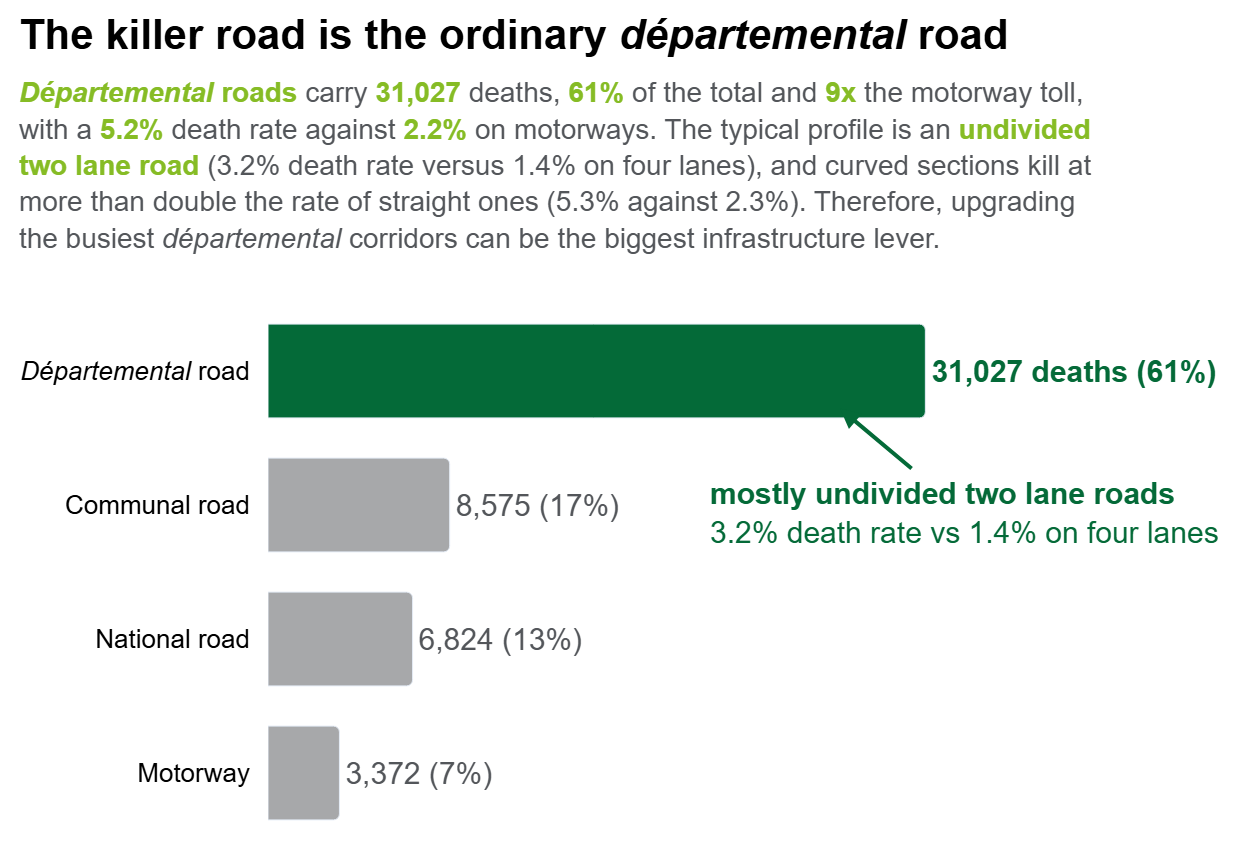

In [ ]:
# Chart 7: Deaths by road type
up = usr.merge(plc[["Num_Acc", "catr"]], on="Num_Acc")
t = up.groupby("catr").agg(persons=("killed", "size"), killed=("killed", "sum"))
t["share"] = 100 * t.killed / t.killed.sum()
DL = "<i>Départemental</i> road"
rows = [("Motorway", t.loc[1]), ("National road", t.loc[2]),
        ("Communal road", t.loc[4]), (DL, t.loc[3])]

fig = go.Figure(go.Bar(
    y=[r[0] for r in rows], x=[r[1].killed for r in rows], orientation="h",
    marker_color=[GRAY, GRAY, GRAY, BLUE], width=0.70,
    text=[f"<b>{r[1].killed:,.0f} deaths ({r[1].share:.0f}%)</b>" if r[0] == DL
          else f"{r[1].killed:,.0f} ({r[1].share:.0f}%)" for r in rows],
    textposition="outside", textfont=dict(color=[DARK, DARK, DARK, BLUE], size=15)))
lay = base_layout("The killer road is the ordinary <i>départemental</i> road",
                 f"{G('<i>Départemental</i>')} {G('roads')} carry {G('31,027')} deaths, "
                 f"{G('61%')} of the total and {G('9x')} the motorway toll, with a "
                 f"{G('5.2%')} death rate against {G('2.2%')} on motorways. The typical profile "
                 f"is an {Gp('undivided two lane road')} (3.2% death rate versus 1.4% on four "
                 "lanes), and curved sections kill at more than double the rate of straight ones "
                 "(5.3% against 2.3%). Therefore, upgrading the busiest <i>départemental</i> corridors "
                 "can be the biggest infrastructure lever.")
lay["xaxis"] = dict(visible=False, range=[0, 45500])
lay["yaxis"] = dict(tickfont=dict(color=INK, size=13), showgrid=False, ticklabelstandoff=8)


fig.update_layout(**lay, barcornerradius=3)
fig.add_annotation(x=27000, y=2.72, ax=62, ay=52, showarrow=True, arrowhead=2,
                   arrowwidth=2, arrowcolor=BLUE, align="left",
                   text="<b>mostly undivided two lane roads</b><br>"
                        "3.2% death rate vs 1.4% on four lanes",
                   font=dict(color=BLUE, size=15, family=FONT),
                   bgcolor="rgba(255,255,255,0.92)", borderpad=3)
save_pair(fig, "final5_roads.png")

from IPython.display import Image, display
display(Image(filename=str(CHARTS / "final5_roads.png"), width=760))

The bars show deaths by road category over the whole period. *Départemental* roads carry **31,027 deaths, 61% of the total** and 9x the motorway toll, with a 5.2% death rate versus 2.2% on motorways. The annotation explains why, these are mostly **undivided two lane roads** (3.2% death rate vs 1.4% on four lanes) and curved sections kill at more than double the rate of straight ones. Implication, upgrading the busiest *départemental* corridors is the single biggest infrastructure lever.

### 2.8. WHERE: Rural accidents are more dangerous

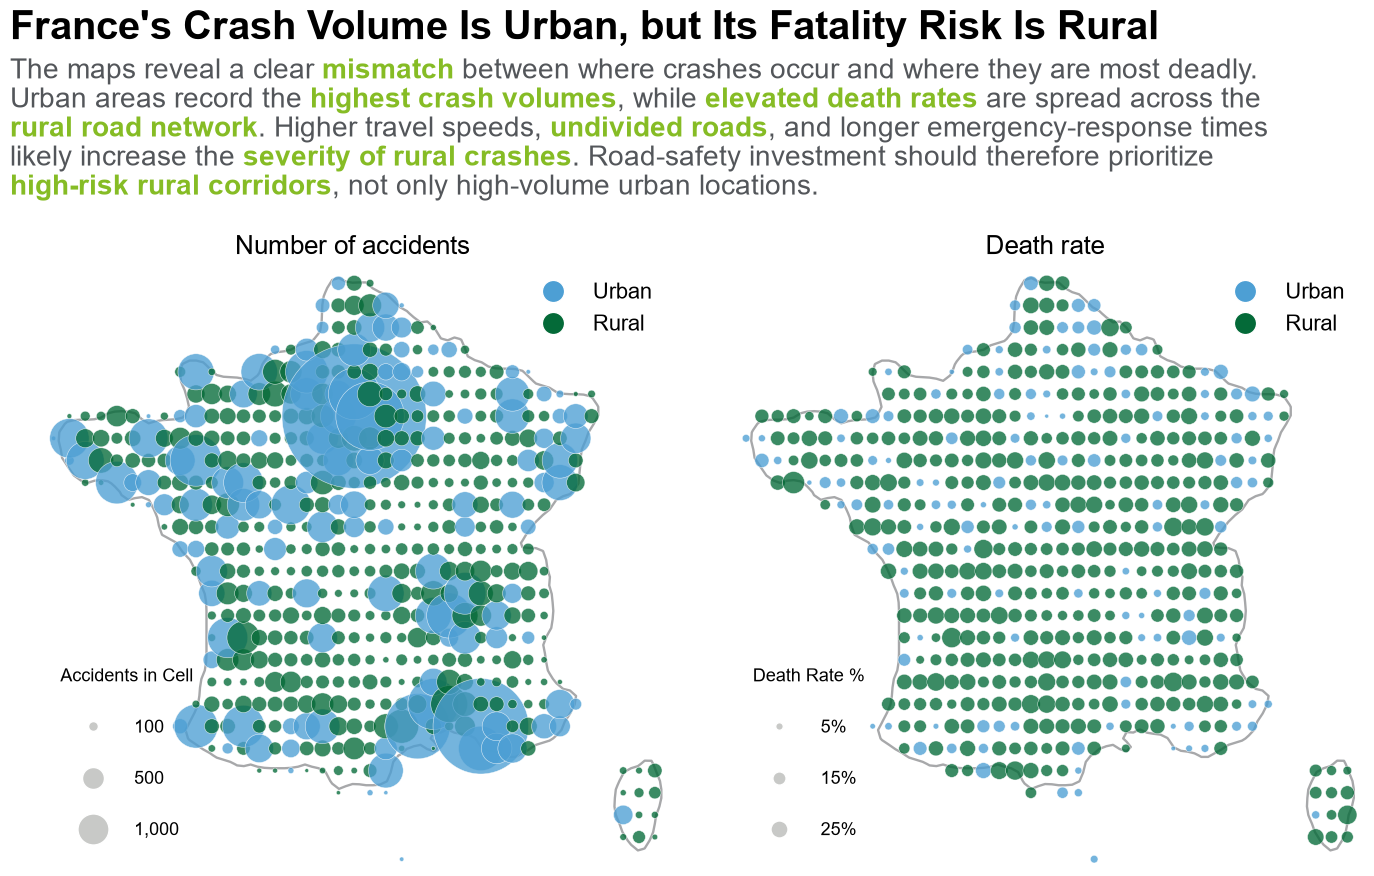

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

plt.rcParams["font.family"] = "Arial"
URBAN, RURAL = "#4d9fd4", "#046A38"   
GREEN, INK, MUTED = "#86BC25", "#000000", "#53565A"
EXTM = (-5.5, 10, 41, 51.5)

# geocoded metropolitan accidents, the 26% of rows that carry usable GPS
lon_all = pd.to_numeric(car.long, errors="coerce")
geo = car[car.lat.notna() & (car.lat != 0) & lon_all.notna() & (lon_all != 0)].copy()
geo["lat_deg"] = geo.lat / 1e5
geo["lon_deg"] = pd.to_numeric(geo.long, errors="coerce") / 1e5
metro = geo[geo.lat_deg.between(41, 51.5) & geo.lon_deg.between(-5.5, 10)].copy()
acc_deaths = usr.groupby("Num_Acc").killed.sum()
metro["deaths"] = metro.Num_Acc.map(acc_deaths).fillna(0)

# France outline 
bx, by = np.linspace(EXTM[0], EXTM[1], 96), np.linspace(EXTM[2], EXTM[3], 73)
occ = (np.histogram2d(metro.lon_deg, metro.lat_deg, bins=[bx, by])[0] > 1).astype(float)
for _ in range(2):
    occ = (occ + np.roll(occ, 1, 0) + np.roll(occ, -1, 0)
           + np.roll(occ, 1, 1) + np.roll(occ, -1, 1)) / 5
bxc, byc = (bx[:-1] + bx[1:]) / 2, (by[:-1] + by[1:]) / 2

step = 0.38
metro["gx"] = np.floor((metro.lon_deg + 5.5) / step)
metro["gy"] = np.floor((metro.lat_deg - 41) / step)
grid = metro.groupby(["gx", "gy"]).agg(n=("agg", "size"), urban=("agg", lambda s: (s == 2).sum()),
                                       deaths=("deaths", "sum")).reset_index()
grid = grid[grid.n >= 15]
grid["cx"] = -5.5 + (grid.gx + 0.5) * step
grid["cy"] = 41 + (grid.gy + 0.5) * step
grid["color"] = np.where(grid.urban >= grid.n / 2, URBAN, RURAL)
grid["dpc"] = 100 * grid.deaths / grid.n

col_h = [Line2D([], [], marker="o", ls="", mfc=URBAN, mec="white", ms=16, label="Urban"),
         Line2D([], [], marker="o", ls="", mfc=RURAL, mec="white", ms=16, label="Rural")]
panels = [("Number of accidents", grid.n, 0.5, "Accidents in Cell", (100, 500, 1000), ""),
          ("Death rate", grid.dpc, 6.0, "Death Rate %", (5, 15, 25), "%")]

fig, axes = plt.subplots(1, 2, figsize=(14, 8.8))
for ax, (title, metric, K, sizelab, sizevals, suf) in zip(axes, panels):
    ax.contour(bxc, byc, occ.T, levels=[0.5], colors="#a7a8aa", linewidths=1.7)
    ax.scatter(grid.cx, grid.cy, s=metric * K, c=grid.color, alpha=0.78,
               edgecolors="white", linewidths=0.4, zorder=3)
    size_h = [Line2D([], [], marker="o", ls="", mfc="#c8c9c7", mec="white",
                     ms=np.sqrt(v * K), label=f"{v:,}{suf}") for v in sizevals]
    lg = ax.legend(handles=size_h, loc="lower left", fontsize=13, title=sizelab, title_fontsize=13,
                   labelspacing=1.9, borderpad=1.0, handletextpad=1.3, frameon=False)
    ax.add_artist(lg)
    ax.legend(handles=col_h, loc="upper right", fontsize=16, frameon=False)
    ax.set_title(title, fontsize=19, color=INK)
    ax.set_aspect(1.4)
    ax.set_xticks([])
    ax.set_yticks([])
    for sp in ax.spines.values():
        sp.set_visible(False)
plt.tight_layout(rect=[0, 0, 1, 0.72])

fig.suptitle("France's Crash Volume Is Urban, but Its Fatality Risk Is Rural",
             fontsize=29, fontweight="bold", color=INK, x=0.008, ha="left", y=0.99)
fig.canvas.draw()
_rend = fig.canvas.get_renderer()


def rich_line(y, text, bolds, size=20):
    x = 0.008
    parts = re.split("(" + "|".join(re.escape(b) for b in bolds) + ")", text) if bolds else [text]
    for part in parts:
        if not part:
            continue
        b = part in bolds
        t = fig.text(x, y, part, fontsize=size, ha="left", va="top", family="Arial",
                     color=GREEN if b else MUTED, fontweight="bold" if b else "normal")
        x += t.get_window_extent(renderer=_rend).width / fig.bbox.width


rich_line(0.935, "The maps reveal a clear mismatch between where crashes occur and where they are "
          "most deadly.", ["mismatch"])
rich_line(0.902, "Urban areas record the highest crash volumes, while elevated death rates are spread "
          "across the", ["highest crash volumes", "elevated death rates"])
rich_line(0.869, "rural road network. Higher travel speeds, undivided roads, and longer emergency-"
          "response times", ["rural road network", "undivided roads"])
rich_line(0.836, "likely increase the severity of rural crashes. Road-safety investment should "
          "therefore prioritize", ["severity of rural crashes"])
rich_line(0.803, "high-risk rural corridors, not only high-volume urban locations.",
          ["high-risk rural corridors"])
plt.show()

## 3. GCP Service

*From the experiment in section 2, which Google Cloud Platform tools or services can be used to easily extract these insights?*

- **BigQuery**: At this scale (~230 MB) the five CSVs can be loaded into BigQuery for stroing and analyzing data. 
- **BigQuery DataFrames or Python**: Clean the data, decode category values, join the tables, and save the prepared dataset back to BigQuery.
- **Looker Studio**: Create interactive dashboards, maps, trends, and département-level analysis for government users.
- **Vertex AI Workbench**: Provide a managed Jupyter Notebook environment for Python analysis, visualization, and team collaboration.
- **Cloud Storage and Dataflow**: Optional for larger future datasets. Cloud Storage can keep raw files, while Dataflow can process automated or streaming accident data.
- **BigQuery ML** can also build accident-severity prediction models directly in BigQuery (if predicition become crucial in the future).

### Flowchart

```mermaid
flowchart LR
    CSV["5 BAAC CSV files<br/>existing (2005-2016)"] --> BQR["BigQuery<br/>raw tables"]
    FEED["New accident data<br/>(future)"] --> BQR
    BQR --> PY["Python cleaning<br/>bigframes in Vertex AI Workbench"]
    PY --> BQC["BigQuery<br/>clean tables/view"]
    BQC --> LS["Looker Studio<br/>dashboards"]
    BQC --> VAI["Vertex AI Workbench<br/>pandas + plotly"]
    BQC --> ML["BigQuery ML<br/>severity models"]
```


![GCP flow](../charts/gcp-flow.png)
